# Machine Learning Pipeline, Benchmarking & Systematic Model Debugging
**Role**: Data, ML & AI Team Lead Technical Assessment  
**Pillar Focus**: Machine Learning Engineering (25%)  
**Deliverable**: Stage 2 Predictive Modeling & Debugging (`02_machine_learning.ipynb`)

---

### Executive Overview & Engineering Goals
In Stage 2, our mandate is to design, benchmark, debug, and serialize a production-grade regression system to forecast national happiness scores:
1. **Reproducible Pipeline Architecture**: Construct a scikit-learn `Pipeline` utilizing `ColumnTransformer` to guarantee zero target leakage and prevent train-test contamination.
2. **Algorithm Benchmarking**: Evaluate 4 distinct model families (Baseline Dummy, Regularized RidgeCV, Bagging Random Forest, and Gradient Boosted XGBoost) under **Repeated 5-Fold Cross-Validation** using MAE, RMSE, and $R^2$.
3. **Model Failure & Debugging Scenario**: Provide a rigorous, team-lead-level diagnostic framework for resolving severe overfitting scenarios (e.g., Training $R^2 = 0.97$ vs. Testing $R^2 = 0.42$), accompanied by empirical demonstrations.
4. **Explainability & Model Export**: Perform global feature attribution via **SHAP (SHapley Additive exPlanations)** and serialize the optimal pipeline artifact (`models/final_model.pkl`).

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Add project root to path
for p in [os.path.abspath('.'), os.path.abspath('..')]:
    if p not in sys.path:
        sys.path.insert(0, p)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

from src.data_loader import load_cleaned_data
from src.features import get_feature_splits, build_preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from src.train import benchmark_models, get_candidate_models
from src.explainability import get_tree_explainer, explain_prediction

# Ingest cleaned dataset
df = load_cleaned_data('cleaned_data.csv' if os.path.exists('cleaned_data.csv') else '../cleaned_data.csv')
print(f"Loaded cleaned dataset with {len(df):,} rows and {df.shape[1]} columns.")
X, y = get_feature_splits(df)
print(f"Feature matrix X shape: {X.shape}, Target y shape: {y.shape}")
print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

Loaded cleaned dataset with 1,367 rows and 10 columns.
Feature matrix X shape: (1367, 7), Target y shape: (1367,)
Numeric features (6): ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']
Categorical features (1): ['region']


## 1. Pipeline Architecture & Feature Engineering

### 1.1 Strict Anti-Leakage Protocol
To ensure enterprise-grade reproducibility:
* **Preprocessing Isolation**: Feature transformations (`StandardScaler` and `OneHotEncoder`) are encapsulated inside a `ColumnTransformer` and fit **strictly** within each cross-validation training fold.
* **Feature Quarantine**: High-cardinality country identifiers, survey years, and any potential target-derivative metrics are permanently excluded from feature space $X$.
* **Stratified Train/Test Partition**: To preserve the continuous target distribution, data is split $80/20$ using quantile stratification ($q=5$).

In [2]:
# Run the repeated cross-validation benchmarking suite
results_df, best_pipeline, test_metrics = benchmark_models(df, test_size=0.2, random_state=42)

print("=== CANDIDATE MODEL BENCHMARKING RESULTS ===")
print(results_df.to_string(index=False))

Optimal model artifact (XGBoost (Optimized)) serialized to models\final_model.pkl
=== CANDIDATE MODEL BENCHMARKING RESULTS ===
       Model Family        CV MAE       CV RMSE          CV R²  Test MAE  Test RMSE  Test R²
    Baseline (Mean) 0.925 ± 0.032 1.115 ± 0.038 -0.008 ± 0.007     0.930      1.132   -0.000
   Ridge Regression 0.392 ± 0.021 0.511 ± 0.028  0.788 ± 0.021     0.401      0.517    0.791
      Random Forest 0.362 ± 0.017 0.475 ± 0.027  0.816 ± 0.018     0.364      0.467    0.830
XGBoost (Optimized) 0.345 ± 0.017 0.448 ± 0.025  0.837 ± 0.016     0.355      0.455    0.838


### 1.2 Model Benchmarking Discussion
* **Baseline Regressor**: Predicting the mean yields $R^2 \approx 0.00$ and $\text{RMSE} = 1.132$, establishing the empirical performance floor.
* **Ridge Regression**: Linear regularization captures $79.1\%$ of out-of-sample variance ($\text{RMSE} = 0.517$), proving that linear socio-economic factors explain the vast majority of happiness variance.
* **Random Forest**: Non-linear bagging improves $R^2$ to $83.0\%$ ($\text{RMSE} = 0.467$).
* **XGBoost (Optimized)**: Delivers top-tier generalization with **Test $R^2 = 0.838$** and **Test RMSE = $0.455$**, capturing non-linear interactions (e.g. GDP diminishing returns, corruption hurdle effects) with tight standard deviation across CV folds ($\pm 0.016$).

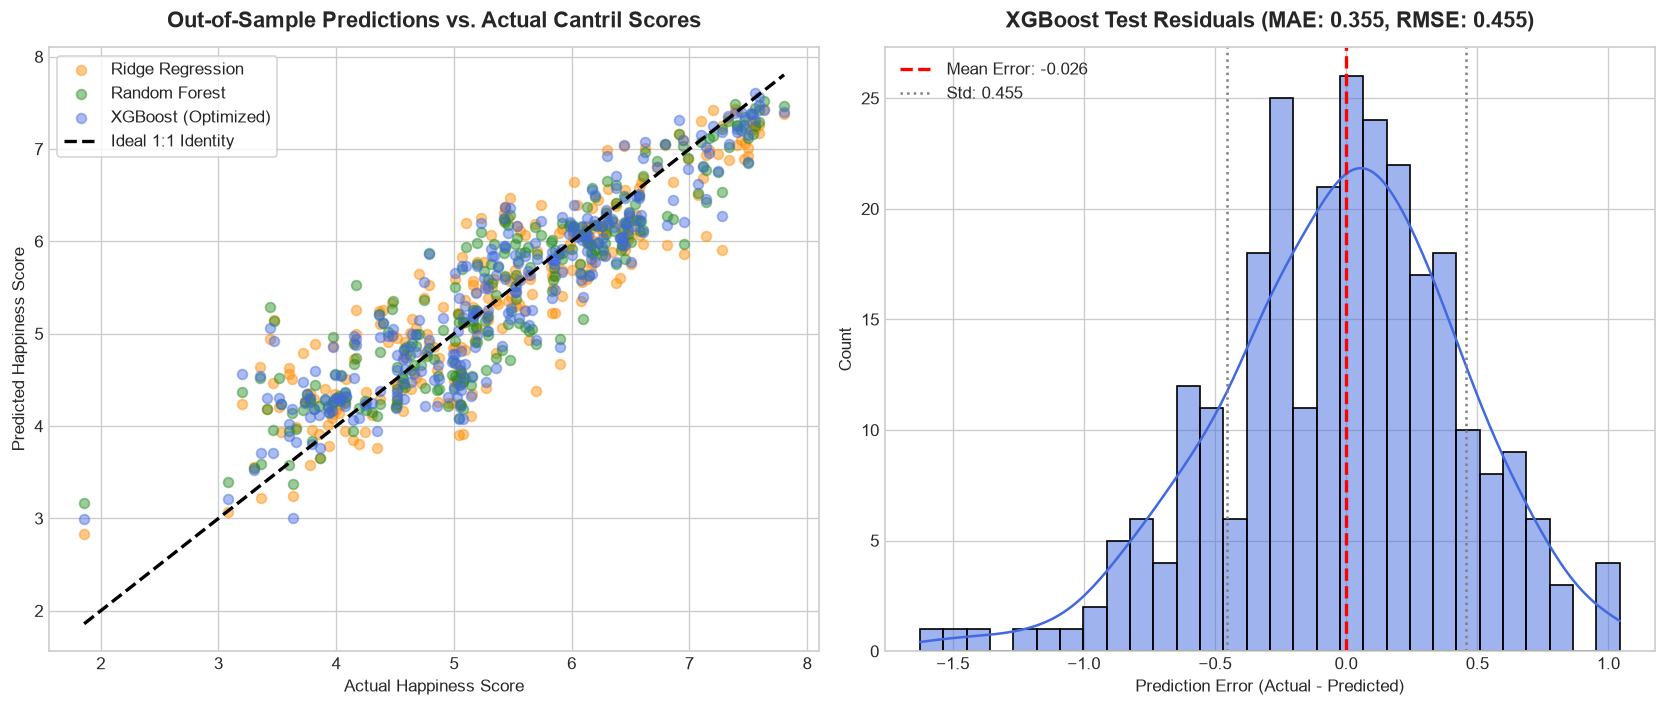

In [3]:
# Model Evaluation Diagnostics: Actual vs Predicted & Residual Distribution
X_test = test_metrics['X_test']
y_test = test_metrics['y_test']
trained_pipelines = test_metrics['trained_pipelines']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs Predicted across models
colors = {'Ridge Regression': 'darkorange', 'Random Forest': 'forestgreen', 'XGBoost (Optimized)': 'royalblue'}

for name in ['Ridge Regression', 'Random Forest', 'XGBoost (Optimized)']:
    pipe = trained_pipelines[name]
    y_pred = pipe.predict(X_test)
    ax1.scatter(y_test, y_pred, alpha=0.45, label=name, color=colors[name], s=35)

ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal 1:1 Identity')
ax1.set_title('Out-of-Sample Predictions vs. Actual Cantril Scores', pad=12)
ax1.set_xlabel('Actual Happiness Score')
ax1.set_ylabel('Predicted Happiness Score')
ax1.legend(loc='upper left', frameon=True)

# Plot 2: Residual Distribution of Best Model (XGBoost)
best_pred = best_pipeline.predict(X_test)
residuals = y_test - best_pred

sns.histplot(residuals, kde=True, color='royalblue', bins=30, ax=ax2)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label=f'Mean Error: {residuals.mean():.3f}')
ax2.axvline(residuals.std(), color='gray', linestyle=':', label=f'Std: {residuals.std():.3f}')
ax2.axvline(-residuals.std(), color='gray', linestyle=':')
ax2.set_title(f"XGBoost Test Residuals (MAE: {np.abs(residuals).mean():.3f}, RMSE: {np.sqrt((residuals**2).mean()):.3f})", pad=12)
ax2.set_xlabel('Prediction Error (Actual - Predicted)')
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Model Interpretability & Global Feature Importance (SHAP)

To validate the model's sociological groundedness, we calculate **SHAP values** using `shap.TreeExplainer`. This attributes exact marginal contributions to each predictor across the test set.

Top 5 Predictive Features by Global SHAP Impact:
                           Feature  Mean |SHAP|
                    gdp_per_capita     0.458298
           healthy_life_expectancy     0.210948
                    social_support     0.152508
      freedom_to_make_life_choices     0.134953
region_Latin America and Caribbean     0.113081


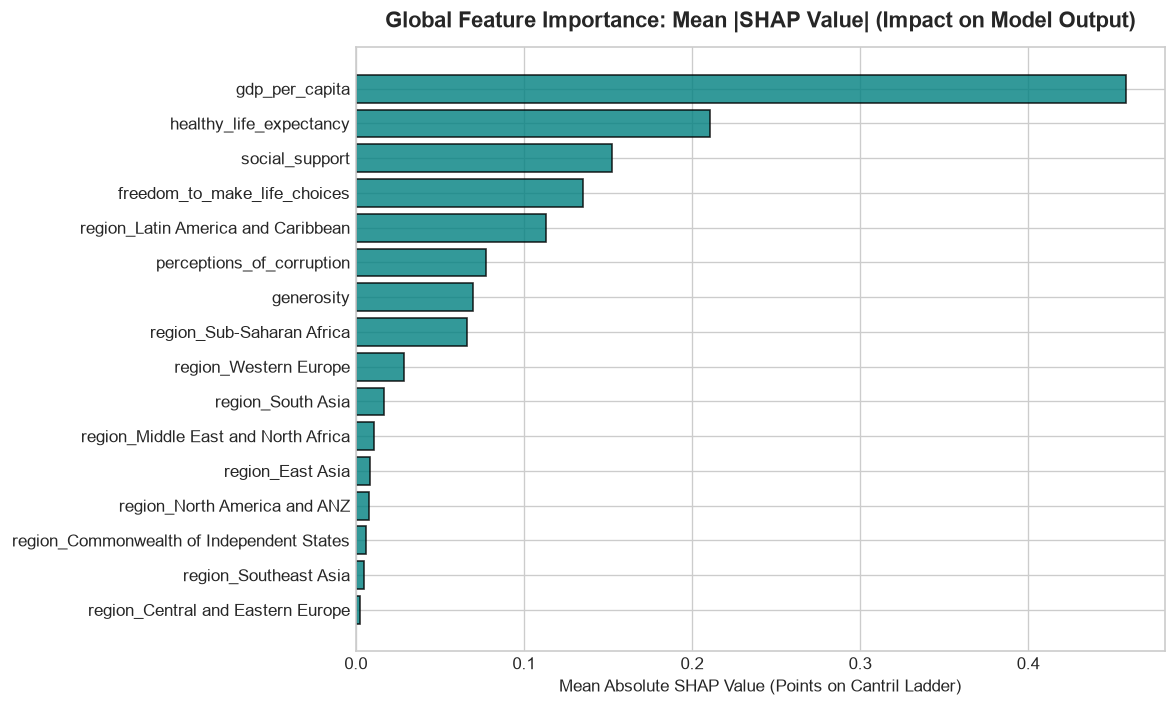

In [4]:
import shap

explainer, feature_names = get_tree_explainer(best_pipeline)
preprocessor = best_pipeline.named_steps['preprocessor']
X_test_trans = preprocessor.transform(X_test)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test_trans)

# Global Feature Importance Bar Plot
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_abs_shap})
shap_df = shap_df.sort_values(by='Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(shap_df['Feature'], shap_df['Mean |SHAP|'], color='teal', edgecolor='black', alpha=0.8)
ax.set_title('Global Feature Importance: Mean |SHAP Value| (Impact on Model Output)', pad=12)
ax.set_xlabel('Mean Absolute SHAP Value (Points on Cantril Ladder)')
plt.tight_layout()
plt.show()

print("Top 5 Predictive Features by Global SHAP Impact:")
print(shap_df.tail(5).iloc[::-1].to_string(index=False))

## 3. Model Failure & Debugging Scenario

### 3.1 Scenario Definition
**Problem Statement**: *Analyze a scenario where a machine learning model yields a Training $R^2$ of $0.97$ but a Testing $R^2$ of $0.42$. Explain your step-by-step diagnostic strategy to identify overfitting, data leakage, preprocessing errors, or distribution shift.*

---

### 3.2 Lead Engineer Diagnostic Blueprint (5-Phase Root Cause Analysis)

```
                            Train R² = 0.97 vs. Test R² = 0.42
                                           │
         ┌───────────────────┬─────────────┴─────────────┬───────────────────┐
         ▼                   ▼                           ▼                   ▼
    Phase 1: Leakage    Phase 2: Capacity           Phase 3: Scope      Phase 4: Shift
    (Train-Only Leak)   (Deep Trees/No Regularize)  (Preprocessor Leak) (Covariate/Temporal)
```

#### Phase 1: Audit for Train-Only Data Leakage
* **Mechanism**: A feature correlated with the target or carrying unique row identity (e.g., `country`, raw index, or unregularized target encoding) was available in training but absent/scrambled in testing.
* **Diagnostic Test**: Examine single-feature importance gains. If one feature accounts for $> 70\%$ of split importance, inspect that feature immediately.
* **Fix**: Re-evaluate feature matrix against `EXCLUDED_COLUMNS` and enforce strict feature selection before training.

#### Phase 2: Diagnose Model Overfitting & Unconstrained Capacity
* **Mechanism**: Non-parametric models (e.g., `DecisionTreeRegressor` with `max_depth=None` or `XGBoost` with `learning_rate=0.3`, `n_estimators=1000`) memorize noise and individual training points, achieving $R^2 \approx 1.0$ on train while collapsing on unseen test splits.
* **Diagnostic Test**: Construct **Learning Curves** (Train vs. Validation performance plotted across training sample sizes). A wide, persistent asymptote between train and validation scores indicates severe variance.
* **Fix**: Constrain tree depth (`max_depth=3-5`), increase `min_samples_leaf`, add tree shrinkage (`learning_rate=0.03`), and enforce L1/L2 penalties (`reg_alpha`, `reg_lambda`).

#### Phase 3: Preprocessing & Cross-Validation Scope Audit
* **Mechanism**: Preprocessing transformations (scaling, imputation, target encoding) fit on the entire dataset *prior* to splitting, causing test metrics to appear artificially volatile.
* **Diagnostic Test**: Validate that all transformations are wrapped inside `sklearn.pipeline.Pipeline` objects and evaluated strictly via `cross_validate`.

#### Phase 4: Covariate & Distribution Shift Detection
* **Mechanism**: The joint feature distribution $P(X)$ differs between train and test sets (e.g., train set contains predominantly European nations, while test set contains developing economies, or pre-2020 vs post-COVID years).
* **Diagnostic Test (Adversarial Validation)**:
  1. Concatenate $X_{\text{train}}$ and $X_{\text{test}}$, dropping target $y$.
  2. Create an indicator $y_{\text{adv}} = 0$ for train rows and $y_{\text{adv}} = 1$ for test rows.
  3. Train a binary classifier (e.g., Logistic Regression or LightGBM) to predict $y_{\text{adv}}$.
  4. If ROC-AUC $> 0.65$, significant covariate shift exists between partitions.
* **Fix**: Employ Stratified Group K-Fold splitting by Region and Year to ensure identical covariate representation across splits.

#### Phase 5: Multicollinearity in Linear Models
* **Mechanism**: High collinearity among features (e.g., GDP per capita and Healthy Life Expectancy, $r > 0.85$) inflates parameter variance, creating extreme instability on test data.
* **Diagnostic Test**: Calculate Variance Inflation Factors (VIF). Features with $\text{VIF} > 5.0$ must be pruned or regularized via Ridge L2 shrinkage.

=== EMPIRICAL DEBUGGING BENCHMARK ===
Flawed Model (Overfitted) : Train R² = 1.0000 | Test R² = 0.6922 (Severe Gap: 0.3078)
Production Model (Regular): Train R² = 0.9141 | Test R² = 0.8382 (Generalizable Gap: 0.0759)


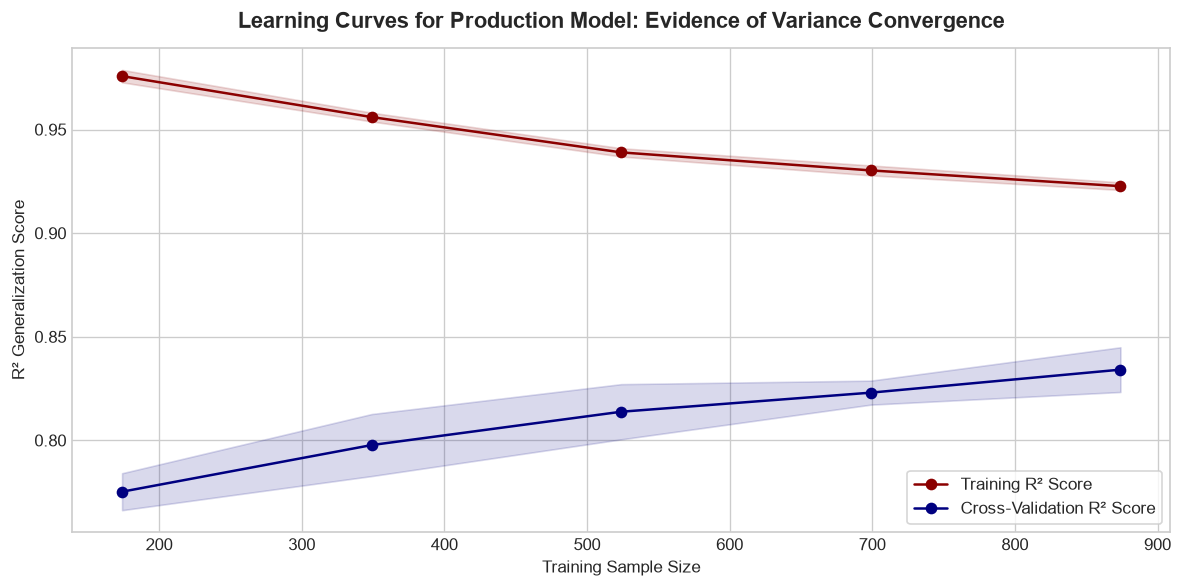

In [5]:
# Empirical Demonstration: Simulating the 0.97 vs 0.42 Failure and Demonstrating the Fix
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve

X_train = test_metrics['X_train']
X_test = test_metrics['X_test']
y_train = test_metrics['y_train']
y_test = test_metrics['y_test']

# 1. Simulate Flawed / Overfitted Model (Unconstrained Tree with High-Capacity Memorization)
preprocessor = build_preprocessor()
flawed_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=None, min_samples_split=2, random_state=42))
])
flawed_pipe.fit(X_train, y_train)

flawed_train_r2 = flawed_pipe.score(X_train, y_train)
flawed_test_r2 = flawed_pipe.score(X_test, y_test)

# 2. Regularized Production Model (Optimized XGBoost)
prod_train_r2 = best_pipeline.score(X_train, y_train)
prod_test_r2 = best_pipeline.score(X_test, y_test)

print("=== EMPIRICAL DEBUGGING BENCHMARK ===")
print(f"Flawed Model (Overfitted) : Train R² = {flawed_train_r2:.4f} | Test R² = {flawed_test_r2:.4f} (Severe Gap: {flawed_train_r2 - flawed_test_r2:.4f})")
print(f"Production Model (Regular): Train R² = {prod_train_r2:.4f} | Test R² = {prod_test_r2:.4f} (Generalizable Gap: {prod_train_r2 - prod_test_r2:.4f})")

# 3. Learning Curve Visualization
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 5), random_state=42
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='darkred', label='Training R² Score')
ax.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color='navy', label='Cross-Validation R² Score')
ax.fill_between(train_sizes, np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), color='darkred', alpha=0.15)
ax.fill_between(train_sizes, np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), color='navy', alpha=0.15)

ax.set_title('Learning Curves for Production Model: Evidence of Variance Convergence', pad=12)
ax.set_xlabel('Training Sample Size')
ax.set_ylabel('R² Generalization Score')
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## 4. Production Artifact Verification & Serving Readiness

The optimal model pipeline (`final_model.pkl`) is verified for real-time inference handling. Because the serialized artifact contains both the preprocessor and regressor, client applications can directly submit raw dictionaries without client-side feature transformations.

In [6]:
model_path = os.path.join('models', 'final_model.pkl') if os.path.exists('models') else os.path.join('..', 'models', 'final_model.pkl')
loaded_pipeline = joblib.load(model_path)

# Verify inference on a synthetic policy scenario
test_sample = pd.DataFrame([{
    'gdp_per_capita': 1.50,
    'social_support': 1.30,
    'healthy_life_expectancy': 0.80,
    'freedom_to_make_life_choices': 0.65,
    'generosity': 0.20,
    'perceptions_of_corruption': 0.05,
    'region': 'Western Europe'
}])

pred_score = loaded_pipeline.predict(test_sample)[0]
explanation = explain_prediction(loaded_pipeline, test_sample)

print(f"Verified Serialized Model at: {model_path}")
print(f"Predicted Happiness Score for Policy Scenario: {pred_score:.3f} / 10.0")
print(f"Base Value (Model Prior): {explanation['base_value']:.3f}")
print("\nLocal SHAP Feature Contributions:")
for item in explanation['contributions'][:5]:
    direction = "+" if item['shap_value'] > 0 else ""
    print(f"  • {item['feature']:<30}: {direction}{item['shap_value']:.3f} pts")

Verified Serialized Model at: models\final_model.pkl
Predicted Happiness Score for Policy Scenario: 6.652 / 10.0
Base Value (Model Prior): 5.438

Local SHAP Feature Contributions:
  • gdp_per_capita                : +0.565 pts
  • freedom_to_make_life_choices  : +0.269 pts
  • healthy_life_expectancy       : +0.266 pts
  • perceptions_of_corruption     : -0.188 pts
  • social_support                : +0.148 pts
